### FLiBe Simple

In [35]:
import openmc
import os, sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib.ticker import MultipleLocator, ScalarFormatter
from scipy.interpolate import make_interp_spline

# Import helper functions
sys.path.insert(0, f"{Path.cwd()}/helper")
from utilities import *

Moved helper functions to their own file in: `./helper/utilities.py`. --ppark 2025-07-02
### Materials
FLiBe density is 1.8 g/cm$^3$ with 20% Li-6 enrichment. In the FLiBe, molar ratio of 2 LiF per BeF$_2$. The system is a volume of 342 m$^3$ at 900 K. We increase tons of U in the system, subtracting FLiBe, from 0 to 50 metric tons (MTU).

> [$\S$2.4] In this work, we investigate what happens when fertile species (U-238 or Th-232) are introduced to the FLiBe LIB in amounts ranging from 5 to 50 metric tons, corresponding to a maximum molar percentage of 1.81% and 1.84% for UF4 and ThF4 respectively, assuming a blanket volume of 342 m$^3$.
>
> [$\S$3.1] The total volume of FLiBe in the model is 342 m$^3$, with no additional volume added to account for FLiBe in other systems like pumps or heat exchangers. This results in a fertile mass loading of $2.92\times10^{−2}$ g cm$^{−3}$ metric ton of fertile material. For this study, examining a range of 5 to 50 metric tons of fertile material, this corresponds to a fertile mass density range of 0.146-1.46 g cm$^{−3}$.

In [60]:
# User specifications
DENSITY_FLIBE = 1.94 # usu 1.8-2.0 g/cc -- Ball uses 1.94 --ppark 2025-07-02
ENRICH_LI = 7.5
MOL_LIF, MOL_BEF2 = 2, 1
TEMP = 900 # K
VOL = 342 * 1e6 # cm3
MASS_U_LIST = [0, 0.1, 1, 2.5, 5, 10, 20 ,30 ,40, 50] # metric tons uranium (MTU)

"""
MATERIALS
"""
flibe = openmc.Material(name="FLiBe", temperature=TEMP)
flibe.add_elements_from_formula('F4Li2Be', enrichment_target='Li6', enrichment_type='wo', enrichment=ENRICH_LI)
flibe.set_density('g/cm3', DENSITY_FLIBE) 


uf4 = openmc.Material(name="U",temperature=TEMP)
uf4.add_elements_from_formula('UF4','wo',0.7204)

# Calculate mol ratios of UF4 and FLiBe, ensure they add up to 1
mass_frac_uf4_list, mass_frac_flibe_list = [], []

mix_list = []
for mtu in [50]: # MASS_U_LIST:
    mass_frac_flibe, mass_frac_uf4 = calc_uf4_flibe_mass_fracs(mtu, volume=VOL, density_flibe=DENSITY_FLIBE)
    mix = openmc.Material.mix_materials([flibe, uf4], [mass_frac_flibe, mass_frac_uf4], 'wo') # fractions in 'mix_materials' MUST add up to 1
    mix.name = f"mat-{mtu:.1f}mtu"
    mix.temperature = TEMP
    print(f"For {mtu:.1f} MTU | {mix.get_nuclide_atom_densities('U238')}")
    mix_list.append(mix)

materials = openmc.Materials(mix_list)

For 50.0 MTU | {'U238': np.float64(9.923487190451302e-05)}


Temporary solution for finding cross sections between several machines

In [37]:
xs_path_zotac = '/opt/openmc_data/endfb-viii.0-hdf5/cross_sections.xml'
xs_path_wsl   = '/mnt/c/openmc/data/endfb-viii.0-hdf5/cross_sections.xml'
if os.path.isfile(xs_path_zotac):
    materials.cross_sections = xs_path_zotac # use this on zotac --ppark
elif os.path.isfile(xs_path_wsl):
    materials.cross_sections = xs_path_wsl
else:
    print(f"Error finding cross section XML!")
    # sys.exit(2)

#### Geometry
For our simple case suppose we make a 1 m$^3$ cube with reflective surfaces of homogeneous FLiBe. We define a cubical cell defined by 6 planes, and place this cell in the "universe." (Alex actually suggested switching from 1 cm side to 1 m side because if the geometry is too small we'll spend too much computational time calculating neutron reflections.) Then, like the materials, we export these definitions to `geometry.xml`.

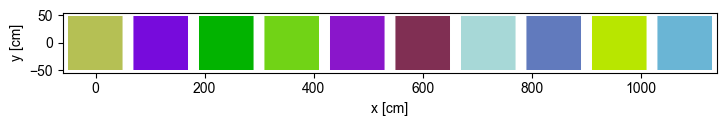

In [38]:
""" GEOMETRY
"""
cells = []
spacing = 120  # enough space between cells to avoid overlap
half_box = 50  # ±50 cm bounds

for i, material in enumerate(mix_list):
    x_offset = i * spacing
    x_min = openmc.XPlane(x0=-half_box + x_offset, boundary_type='reflective')
    x_max = openmc.XPlane(x0=half_box + x_offset, boundary_type='reflective')
    ymin = openmc.YPlane(-50, boundary_type='reflective')
    ymax = openmc.YPlane( 50, boundary_type='reflective')
    zmin = openmc.ZPlane(-50, boundary_type='reflective')
    zmax = openmc.ZPlane( 50, boundary_type='reflective')
    region = +x_min & -x_max & +ymin & -ymax & +zmin & -zmax
    cell = openmc.Cell(fill=material, region=region)
    cell.name = f"mix-{i+1}"
    cells.append(cell)

# Create root universe with all material cells
root_univ = openmc.Universe(cells=cells)

# Visualization and geometry definition
root_univ.plot(width=(spacing * len(mix_list), 110), origin=(spacing * (len(mix_list) - 1) / 2, 0.0, 0.0))
geometry = openmc.Geometry(root_univ)

# geometry.export_to_xml("./xml/geometry.xml") # don't need bc 'model.export_to_model_xml' below --ppark 2025-06-28

#### Settings
Here we define the other settings for our problem. 

In [39]:
""" 
SETTINGS
"""
settings = openmc.Settings()

""" Tallies
"""
E_bin_edges = logspace_per_decade(1e-5, 20e6, 100)
energy_filter = openmc.EnergyFilter(E_bin_edges)
# energy_filter = openmc.EnergyFilter.from_group_structure('CCFE-709')
#   These have extra bins in key energy ranges. A full list of energy structures is available here: --ppark 2025-06-27
#   https://github.com/openmc-dev/openmc/blob/6254be37582e09acff038f5656332b89e53e4eae/openmc/mgxs/__init__.py#L50-L420

tallies = openmc.Tallies() # initialize
cell_filter_map = {}

for i, cell in enumerate(cells):  # filter for each cell of mass composition
    cell_filter = openmc.CellFilter(cell)
    cell_filter_map[cell.id] = cell.name 
    filters = [energy_filter, cell_filter]

    # Flux tally
    flux_tally = openmc.Tally(name=f'flux tally - {cell.name}')
    flux_tally.scores = ['flux'] # specific names required
    # flux_tally.nuclides = ['U238', 'U235']
    flux_tally.filters = filters

    # (Uranium) Tally
    U_tally = openmc.Tally(name=f'U tally - {cell.name}')
    U_tally.scores = ['(n,gamma)','fission', 'elastic'] # specific names required
    U_tally.nuclides = ['U238', 'U235']
    U_tally.filters = filters

    # (Li) Tally
    Li_tally = openmc.Tally(name=f'Li tally - {cell.name}')
    Li_tally.scores = ['(n,gamma)','(n,t)', 'elastic'] # specific names required
    Li_tally.nuclides = ['Li6', 'Li7']
    Li_tally.filters = filters

    # (F) Tally
    F_tally = openmc.Tally(name=f'F tally - {cell.name}')
    F_tally.scores = ['(n,gamma)', 'elastic'] # specific names required
    F_tally.nuclides = ['F19']
    F_tally.filters = filters

    # (Be) Tally
    Be_tally = openmc.Tally(name=f'Be tally - {cell.name}')
    Be_tally.scores = ['(n,gamma)','(n,2n)', 'elastic'] # specific names required
    Be_tally.nuclides = ['Be9']
    Be_tally.filters = filters
    
    # Microscopic cross section tally for U isotopes
    U_micro = openmc.Tally(name=f'U microxs - {cell.name}')
    U_micro.scores = ['fission', '(n,gamma)', 'elastic']
    U_micro.nuclides = ['U235', 'U238']
    U_micro.filters = [cell_filter]
    U_micro.multiply_density = False  # key line

    # Microscopic cross section tally for Li
    Li_micro = openmc.Tally(name=f'Li microxs - {cell.name}')
    Li_micro.scores = ['(n,t)', 'elastic']
    Li_micro.nuclides = ['Li6', 'Li7']
    Li_micro.filters = [cell_filter]
    Li_micro.multiply_density = False

    # Total-energy reaction rates per incident neutron for U isotopes
    U_tot = openmc.Tally(name=f'U totals - {cell.name}')
    U_tot.scores = ['fission', '(n,gamma)', 'elastic']
    U_tot.nuclides = ['U235', 'U238']
    U_tot.filters = [cell_filter]

    # Total-energy reaction rates per incident neutron for U isotopes
    Li_tot = openmc.Tally(name=f'Li totals - {cell.name}')
    Li_tot.scores = ['(n,t)', 'elastic']
    Li_tot.nuclides = ['Li6', 'Li7']
    Li_tot.filters = [cell_filter]

    tallies.extend([flux_tally, U_tally, Li_tally, F_tally, Be_tally, U_micro, Li_micro, U_tot, Li_tot])

    # tallies.export_to_xml("./xml/tallies.xml") --don't need bc 'model.export_to_model_xml' below --ppark 2025-06-28

""" 
Source
  Isotropic 14.07 MeV point source at center of each cube
"""
points = [(0,0,0),(120,0,0),(240,0,0),(360,0,0),(480,0,0),(600,0,0),(720,0,0),(840,0,0),(960,0,0),(1080,0,0)]
source = []
for p in points:
    src = openmc.IndependentSource()
    src.space  = openmc.stats.Point(p)
    src.angle  = openmc.stats.Isotropic()
    src.energy = openmc.stats.Discrete([14.07e6], [1.0])
    source.append(src)

settings.source = source

"""
Run type
"""
settings.run_mode = 'fixed source'
settings.particles = int(1e6) 
settings.batches = 100
settings.inactive = 10

# settings.export_to_xml("./xml/settings.xml") # don't need bc 'model.export_to_model_xml' below --ppark 2025-06-28

#### Run OpenMC

In [40]:
model = openmc.model.Model(geometry, materials, settings, tallies)
model.export_to_model_xml("./model/") 
results_NSlow = model.run(cwd="./model/") 

                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################

In [41]:
# open the results file

tally_data = {}
microxs_data = {}
with openmc.StatePoint(results_NSlow) as sp:
    for cell in cells:                                            
        cell_name = cell.name
        if cell_name not in tally_data:
            tally_data[cell_name] = {}
        if cell_name not in microxs_data:
            microxs_data[cell_name] = {}

        tally_names = ['flux tally', 'U tally', 'Li tally', 'F tally', 'Be tally']
        for name in tally_names:
            full_name = f'{name} - {cell_name}'
            tally = sp.get_tally(name=full_name)
            tally_data[cell_name][name] = tally
        
        microxs_names = ['U microxs', 'Li microxs']
        for namexs in microxs_names:
            micro = f'{namexs} - {cell_name}'
            tallyxs = sp.get_tally(name=micro)
            microxs_data[cell_name][namexs] = tallyxs

cell_summary = {}
bin_summary = {}
microxs_summary = {}

for cell_name, tallies in tally_data.items():
    flux_tally = tallies['flux tally']
    U_tally = tallies['U tally']
    Li_tally = tallies['Li tally']

    # Extract binned tallies
    flux = flux_tally.get_values(scores=['flux']).sum()
    U235 = U_tally.get_values(scores=['fission'], nuclides=['U235']).sum()
    U238 = U_tally.get_values(scores=['fission'], nuclides=['U238']).sum()
    U238_ng = U_tally.get_values(scores=['(n,gamma)'], nuclides=['U238']).sum()
    Li6 = Li_tally.get_values(scores=['(n,t)'], nuclides=['Li6']).sum()
    
    flux_binned = flux_tally.get_values(scores=['flux']).flatten()
    U235_fission_binned = U_tally.get_values(scores=['fission'],nuclides=['U235']).flatten()
    U238_fission_binned = U_tally.get_values(scores=['fission'],nuclides=['U238']).flatten()
    U238_gamma_binned   = U_tally.get_values(scores=['(n,gamma)'],nuclides=['U238']).flatten()
    Li6_tritium_binned  = Li_tally.get_values(scores=['(n,t)'],nuclides=['Li6']).flatten()
    
    
    cell_summary[cell_name] = {
        'Total_flux': flux,
        'U235_fission': U235,
        'U238_fission': U238,
        'U238_gamma': U238_ng,
        'Li6_tritium': Li6,
        }
    bin_summary[cell_name] = {
        'flux_binned': flux_binned,
        'U235_fission_binned': U235_fission_binned,
        'U238_fission_binned': U238_fission_binned,
        'U238_gamma_binned': U238_gamma_binned,
        'Li6_tritium_binned': Li6_tritium_binned
        }
for cell_name, microxs in microxs_data.items():
    U_tallyxs = microxs['U microxs']
    # print('utal', U_tallyxs)
    Li_tallyxs = microxs['Li microxs']

    # Extract binned tallies
    U235 = U_tallyxs.get_values(scores=['fission'], nuclides=['U235']).sum()
    U238 = U_tallyxs.get_values(scores=['fission'], nuclides=['U238']).sum()
    U238_ng = U_tallyxs.get_values(scores=['(n,gamma)'], nuclides=['U238']).sum()
    Li6 = Li_tallyxs.get_values(scores=['(n,t)'], nuclides=['Li6']).sum()
    microxs_summary[cell_name] = {
        'U235_fission': U235,
        'U238_fission': U238,
        'U238_gamma': U238_ng,
        'Li6_tritium': Li6,
        }
    
"""
print(f"Reaction Rates per source neutron")
print(f"for 0 tons total_flux   {cell_summary['mix-1']['Total_flux']} \n" \
      f"            U235_fission {cell_summary['mix-1']['U235_fission']} \n" \
      f"            U238_fission {cell_summary['mix-1']['U238_fission']} \n" \
      f"            U238_gamma   {cell_summary['mix-1']['U238_gamma']}   \n" \
      f"            Li6_tritium  {cell_summary['mix-1']['Li6_tritium']}  \n")
print(f"for 20 tons total_flux   {cell_summary['mix-7']['Total_flux']} \n" \
      f"            U235_fission {cell_summary['mix-7']['U235_fission']} \n" \
      f"            U238_fission {cell_summary['mix-7']['U238_fission']} \n" \
      f"            U238_gamma   {cell_summary['mix-7']['U238_gamma']}   \n" \
      f"            Li6_tritium  {cell_summary['mix-7']['Li6_tritium']}  \n")
"""
mix_labels = [f"mix-{i+1}" for i in range(len(MASS_U_LIST))]

# Loop through and print each set of microXS data
print(f"Reaction average probability per source neutron")
for label, mass in zip(mix_labels, MASS_U_LIST):
    summary = microxs_summary[label]
    print(f"{mass} tons U235 fis   {summary['U235_fission']}")
    print(f"{mass} tons U238 fis   {summary['U238_fission']}")
    print(f"{mass} tons U238 gam   {summary['U238_gamma']}")
    print(f"{mass} tons Li6 trit   {summary['Li6_tritium']}")
    print('-' * 40)
print(f"units of cm^2, rxn probability per source neutron")

Reaction average probability per source neutron
0 tons U235 fis   0.0
0 tons U238 fis   0.0
0 tons U238 gam   110.63428604115614
0 tons Li6 trit   219.55565117732502
----------------------------------------
0.1 tons U235 fis   494.3400844427591
0.1 tons U238 fis   38.29058042787214
0.1 tons U238 gam   110.44109575234401
0.1 tons Li6 trit   219.44642313765885
----------------------------------------
1 tons U235 fis   493.91605187237553
1 tons U238 fis   38.244388135752935
1 tons U238 gam   110.18326484239904
1 tons Li6 trit   219.27254059657193
----------------------------------------
2.5 tons U235 fis   493.95194634286946
2.5 tons U238 fis   38.15834016164837
2.5 tons U238 gam   109.98712225150608
2.5 tons Li6 trit   219.38055893972785
----------------------------------------
5 tons U235 fis   493.7650916982078
5 tons U238 fis   38.05916263241538
5 tons U238 gam   109.56100753166564
5 tons Li6 trit   219.42748530510286
----------------------------------------
10 tons U235 fis   492.767

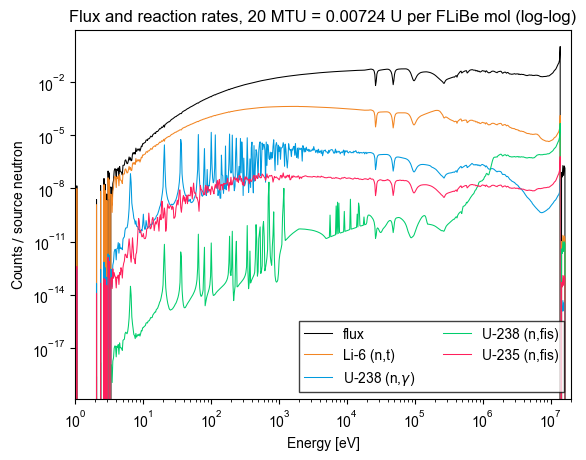

In [42]:
E_bin_centers = E_bin_edges[:-1]

plt.figure()
plt.plot(E_bin_centers, bin_summary['mix-7']['flux_binned']/10,         linewidth=0.75, color='#000000', label=r'flux')
# tracklength estimate of neutron flux per energy bin per neutron

plt.plot(E_bin_centers, bin_summary['mix-7']['Li6_tritium_binned']/10,  linewidth=0.75, color='#f28522', label=r'Li-6 (n,t)')
# total (n,t) reactions on Li-6 to produce tritium per energy bin per neutron

plt.plot(E_bin_centers, bin_summary['mix-7']['U238_gamma_binned']/10,   linewidth=0.75, color='#009ade', label=r'U-238 (n,$\gamma$)')
# total (n,γ) reactions on U238 to produce plutonium per energy bin per neutron

plt.plot(E_bin_centers, bin_summary['mix-7']['U238_fission_binned']/10, linewidth=0.75, color='#00cd6c', label=r'U-238 (n,fis)')
plt.plot(E_bin_centers, bin_summary['mix-7']['U235_fission_binned']/10, linewidth=0.75, color='#ff1f5b', label=r'U-235 (n,fis)')
#total fission reactions on U-238 / U-235 per neutron


#plotting rxns / 10 since each rxn is divided by the total number of incident neutrons
#but that number is the sum of our 10 total neutron sources

plt.xscale('log')
plt.yscale('log')
plt.xlim(1e0,2e7)
plt.xlabel('Energy [eV]')
plt.ylabel('Counts $/$ source neutron')
plt.title('Flux and reaction rates, 20 MTU = 0.00724 U per FLiBe mol (log-log)')
leg = plt.legend(loc='lower right', ncols=2, frameon=True, fancybox=False, edgecolor='black', framealpha=.75,) # fontsize='small', ncols=1, 
leg.get_frame().set_linewidth(1)

os.makedirs('./figures/', exist_ok=True)
plt.savefig('./figures/fig_20mtu_tallies_log-log.pdf', bbox_inches='tight', format='pdf')
plt.savefig('./figures/fig_20mtu_tallies_log-log.png', bbox_inches='tight', format='png')

plt.show()

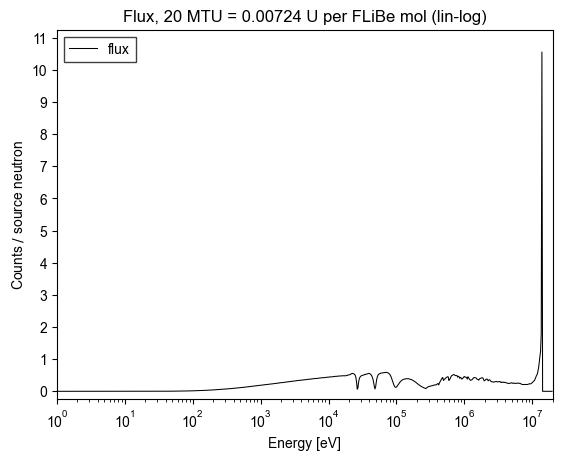

In [25]:
plt.figure()
plt.plot(E_bin_centers, bin_summary['mix-7']['flux_binned'], linewidth=0.75, color='#000000', label=r'flux')
plt.xscale('log')
plt.yscale('linear')
plt.xlim(1e0,2e7)
plt.ylim(-0.25,11.25)

plt.gca().yaxis.set_major_locator(MultipleLocator(1)) # force y ticks at every integer

plt.xlabel('Energy [eV]')
plt.ylabel('Counts $/$ source neutron')
plt.title('Flux, 20 MTU = 0.00724 U per FLiBe mol (lin-log)')
leg = plt.legend(loc='upper left', ncols=2, frameon=True, fancybox=False, edgecolor='black', framealpha=.75,) # fontsize='small', ncols=1, 
leg.get_frame().set_linewidth(1)

os.makedirs('./figures/', exist_ok=True)
plt.savefig('./figures/fig_20mtu_flux_lin-log.pdf', bbox_inches='tight', format='pdf')
plt.savefig('./figures/fig_20mtu_flux_lin-log.png', bbox_inches='tight', format='png')
plt.show()

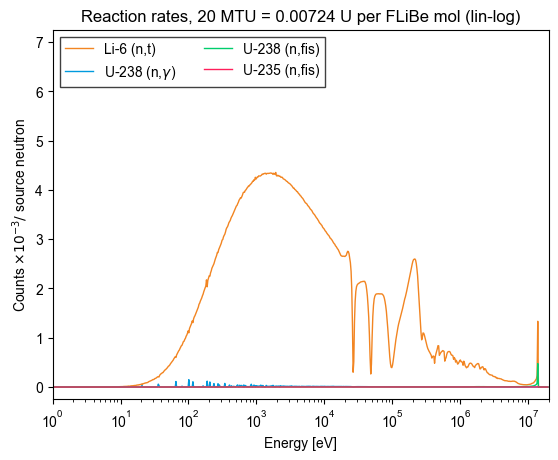

In [43]:
plt.figure()

# plt.plot(E_bin_centers, flux_binned,         linewidth=1, color='#000000', label=r'flux')
plt.plot(E_bin_centers, bin_summary['mix-7']['Li6_tritium_binned']*1e3,  linewidth=1, color='#f28522', label=r'Li-6 (n,t)')
plt.plot(E_bin_centers, bin_summary['mix-7']['U238_gamma_binned']*1e3,   linewidth=1, color='#009ade', label=r'U-238 (n,$\gamma$)')
plt.plot(E_bin_centers, bin_summary['mix-7']['U238_fission_binned']*1e3, linewidth=1, color='#00cd6c', label=r'U-238 (n,fis)')
plt.plot(E_bin_centers, bin_summary['mix-7']['U235_fission_binned']*1e3, linewidth=1, color='#ff1f5b', label=r'U-235 (n,fis)')

plt.xscale('log')
plt.yscale('linear')
plt.xlim(1e0,2e7)
plt.ylim(-0.25,7.25)
# force scientific notation on y-axis
# plt.gca().yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
# plt.gca().ticklabel_format(style='sci', axis='y', scilimits=(0,0))

plt.xlabel('Energy [eV]')
plt.ylabel(r'Counts $\times 10^{-3}/$ source neutron')
plt.title('Reaction rates, 20 MTU = 0.00724 U per FLiBe mol (lin-log)')

leg = plt.legend(loc='upper left', ncols=2, frameon=True, fancybox=False, edgecolor='black', framealpha=.75,) # fontsize='small', ncols=1, 
leg.get_frame().set_linewidth(1)
# plt.tight_layout()
os.makedirs('./figures/', exist_ok=True)
plt.savefig('./figures/fig_20mtu_tallies_lin-log.pdf', bbox_inches='tight', format='pdf')
plt.savefig('./figures/fig_20mtu_tallies_lin-log.png', bbox_inches='tight', format='png')
plt.show()

[np.float64(0.0), np.float64(2.1398915998527525e-05), np.float64(0.00021358108474010237), np.float64(0.0005333831799808199), np.float64(0.0010639009072631043), np.float64(0.0021121672419867174), np.float64(0.00417827270686617), np.float64(0.006219615366940036), np.float64(0.008240397365241242), np.float64(0.0102478995680611)]
[0.         0.00021399 0.00021358 0.00021335 0.00021278 0.00021122
 0.00020891 0.00020732 0.00020601 0.00020496]


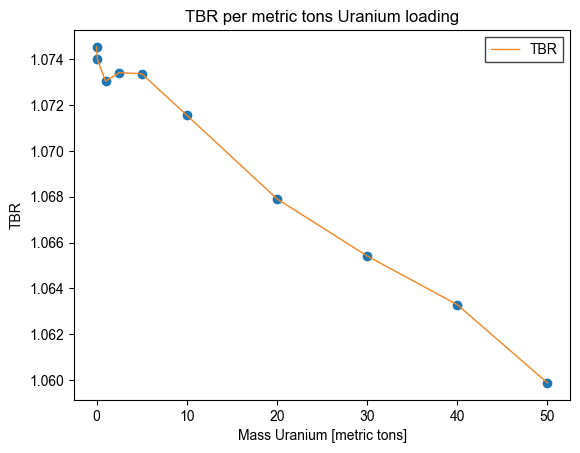

[np.float64(0.0), np.float64(2.1398915998527525e-05), np.float64(0.00021358108474010237)]


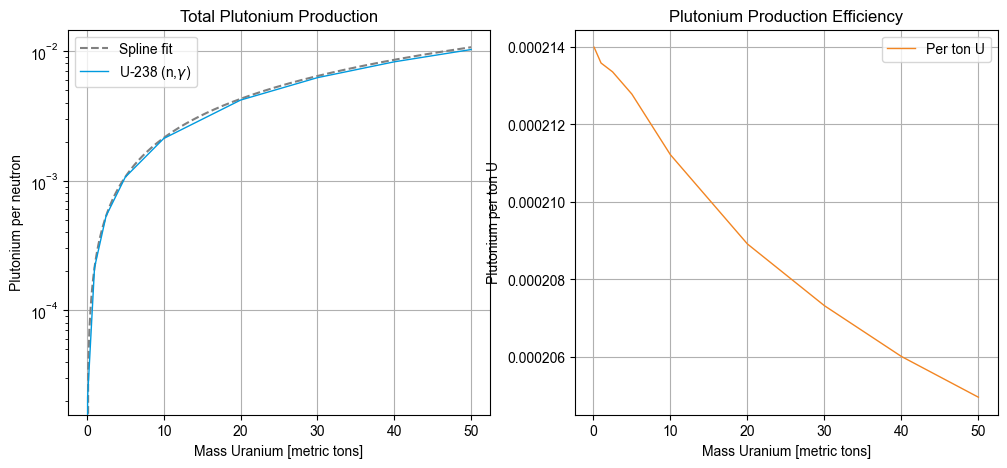

In [48]:
tot_tritium = []    
tot_plutonium = []  

for cell_name, summary in cell_summary.items():
    tot_tritium.append(summary['Li6_tritium'])
    tot_plutonium.append(summary['U238_gamma'])
print(tot_plutonium)
efficiency = np.divide(np.array(tot_plutonium), np.array(MASS_U_LIST), where=np.array(MASS_U_LIST)!= 0)  
print(efficiency)
    
plt.figure()
plt.scatter(MASS_U_LIST, tot_tritium,)
plt.plot(MASS_U_LIST, tot_tritium,  linewidth=1, color='#f28522', label=r'TBR')
plt.xscale('linear')
plt.yscale('linear')
plt.xlabel('Mass Uranium [metric tons]')
plt.ylabel(r'TBR')
plt.title('TBR per metric tons Uranium loading')

leg = plt.legend(loc='upper right', ncols=2, frameon=True, fancybox=False, edgecolor='black', framealpha=.75,) # fontsize='small', ncols=1, 
leg.get_frame().set_linewidth(1)
os.makedirs('./figures/', exist_ok=True)
plt.savefig('./figures/fig_tbr.pdf', bbox_inches='tight', format='pdf')
plt.savefig('./figures/fig_tbr.png', bbox_inches='tight', format='png')
plt.show()

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Total plutonium production

xnew = np.linspace(MASS_U_LIST[0], MASS_U_LIST[9], 300)
masses_new = [0,0.1,1]
ynew = [tot_plutonium[0], tot_plutonium[1], tot_plutonium[2]]
print(ynew)
spl = make_interp_spline(masses_new, ynew, k=1)
ysmooth = spl(xnew)
axs[0].plot(xnew, ysmooth, '--', color='gray', label='Spline fit')
axs[0].plot(MASS_U_LIST, tot_plutonium, linewidth=1, color='#009ade', label=r'U-238 (n,$\gamma$)')
axs[0].set_xlabel('Mass Uranium [metric tons]')
axs[0].set_ylabel('Plutonium per neutron')
axs[0].set_title('Total Plutonium Production')
axs[0].set_yscale('log') 
axs[0].grid(True)
axs[0].legend(loc='upper left', frameon=True)

# Plot 2: Efficiency
axs[1].plot(MASS_U_LIST[1:], efficiency[1:], linewidth=1, color='#f28522', label='Per ton U')
axs[1].set_xlabel('Mass Uranium [metric tons]')
axs[1].set_ylabel('Plutonium per ton U')
axs[1].set_title('Plutonium Production Efficiency')
axs[1].grid(True)
axs[1].legend(loc='upper right', frameon=True)

plt.savefig('./figures/fig_plutonium_dualplot.pdf', bbox_inches='tight', format='pdf')
plt.savefig('./figures/fig_plutonium_dualplot.png', bbox_inches='tight', format='png')
plt.show()

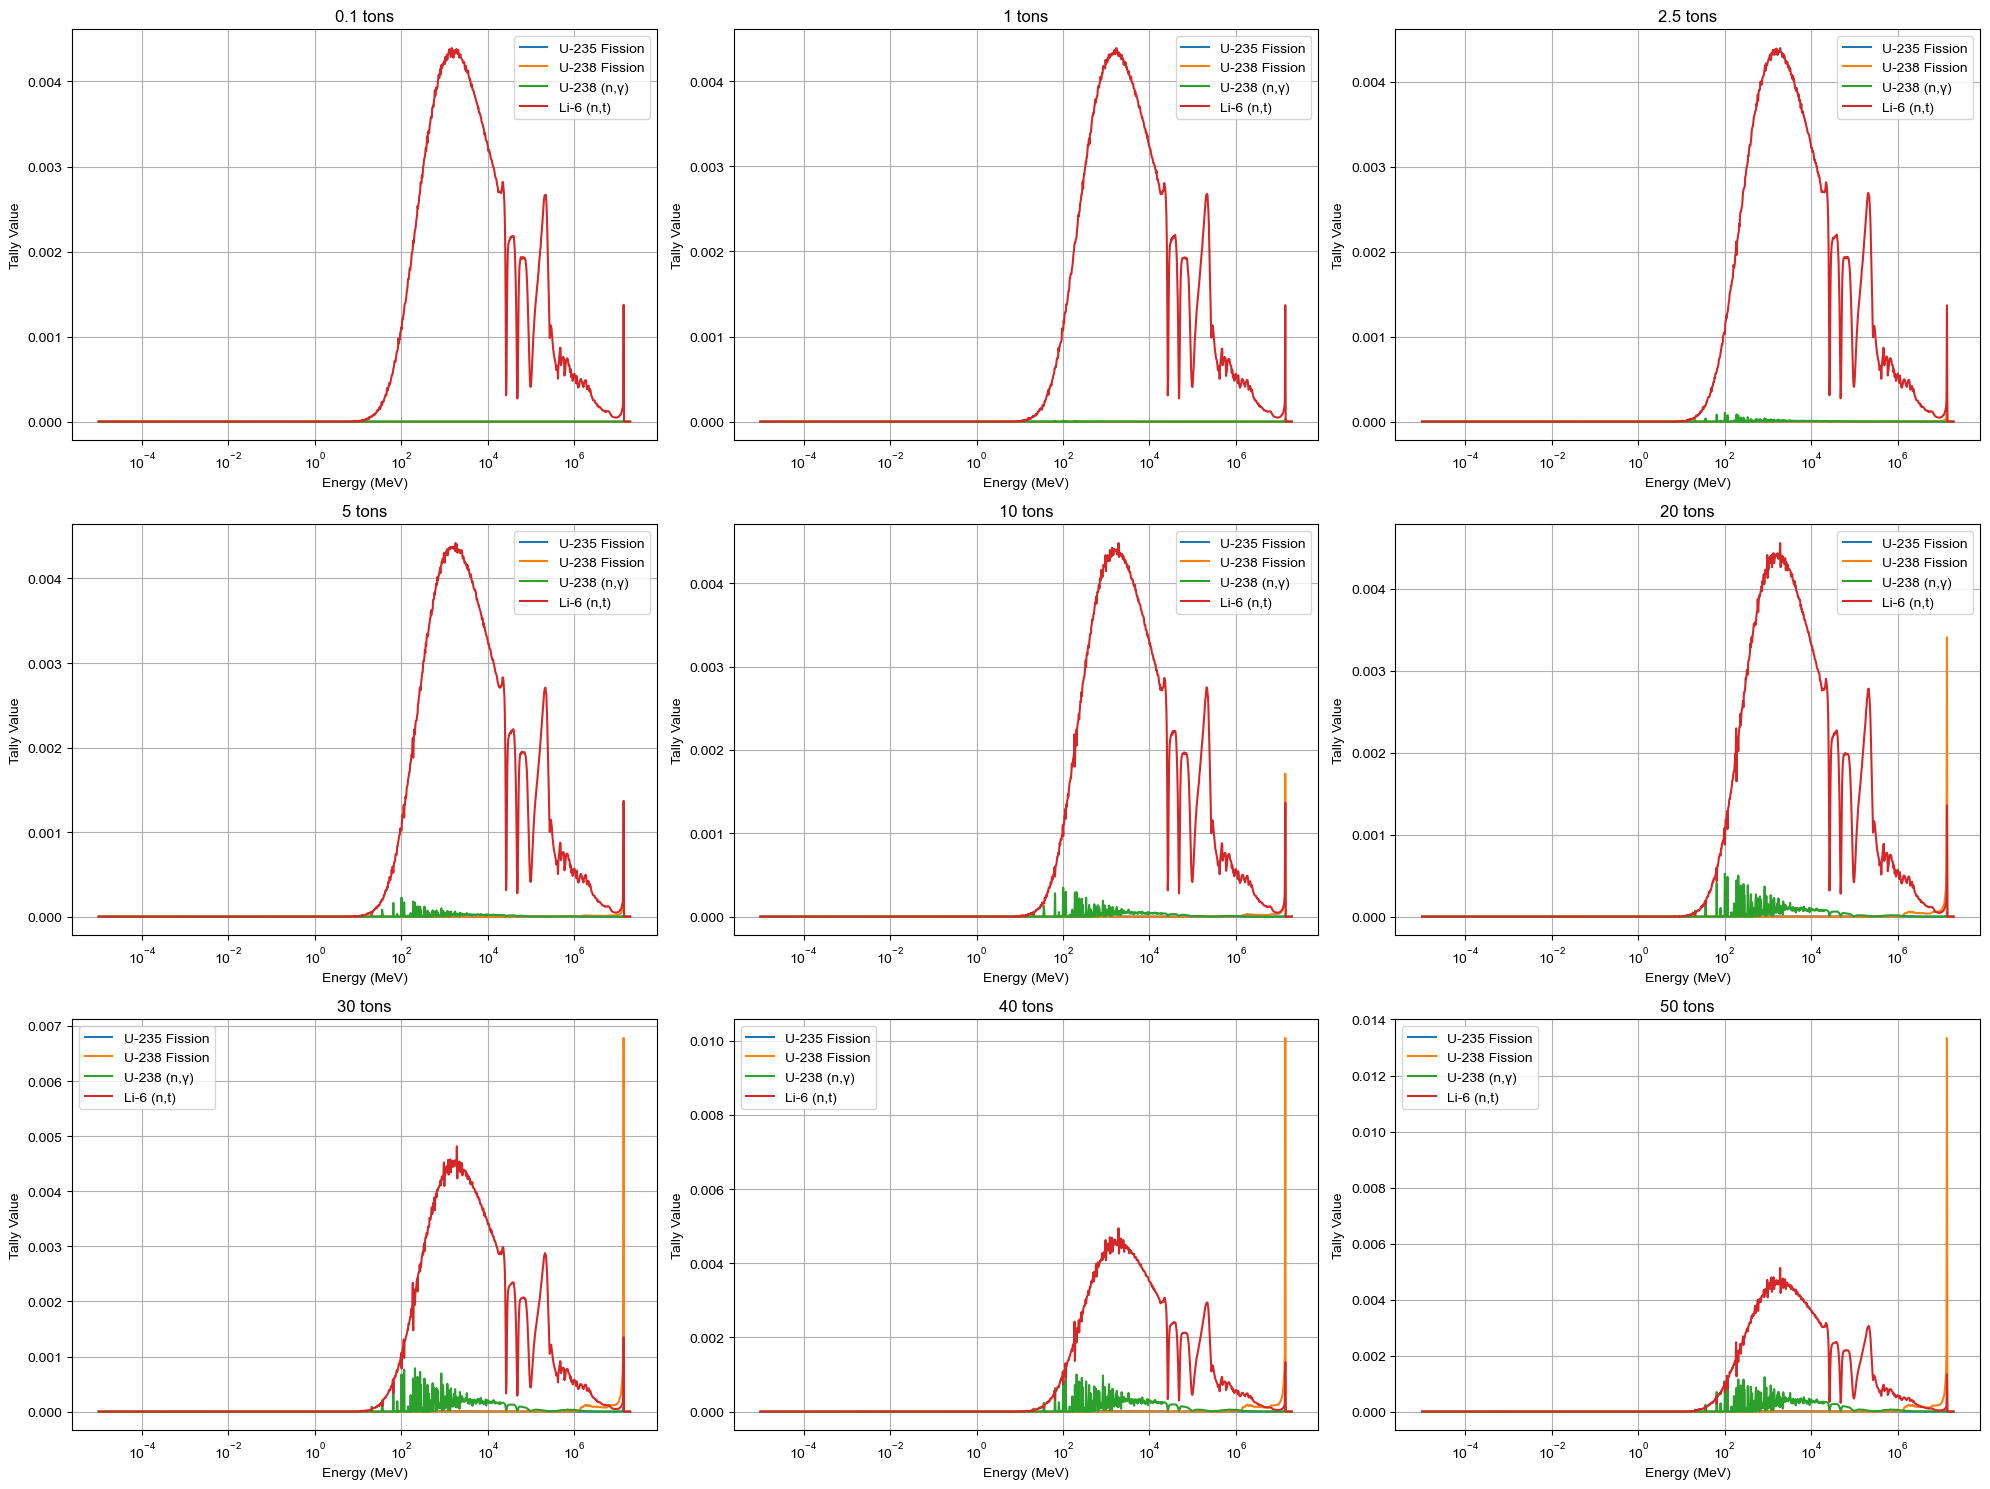

In [50]:
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(20, 15))
axes = axes.flatten()

# Define what to plot
reaction_keys = ['U235_fission_binned', 'U238_fission_binned', 'U238_gamma_binned', 'Li6_tritium_binned']
reaction_labels = ['U-235 Fission', 'U-238 Fission', 'U-238 (n,γ)', 'Li-6 (n,t)']

# Loop through mixes and plot each reaction in a subplot
for i, (label, mass) in enumerate(zip(mix_labels, U_masses)):
    ax = axes[i]
    
    # Plot each reaction type as a line or scatter
    for rxn_key, rxn_label in zip(reaction_keys, reaction_labels):
        if label in bin_summary:
            y = bin_summary[label][rxn_key]
            ax.plot(E_bin_centers, y, label=rxn_label)
    
    ax.set_title(f"{mass} tons")
    ax.set_xlabel("Energy (MeV)")
    ax.set_xscale('log')
    ax.set_ylabel("Tally Value")
    ax.legend()
    ax.grid()

plt.tight_layout()
plt.show()

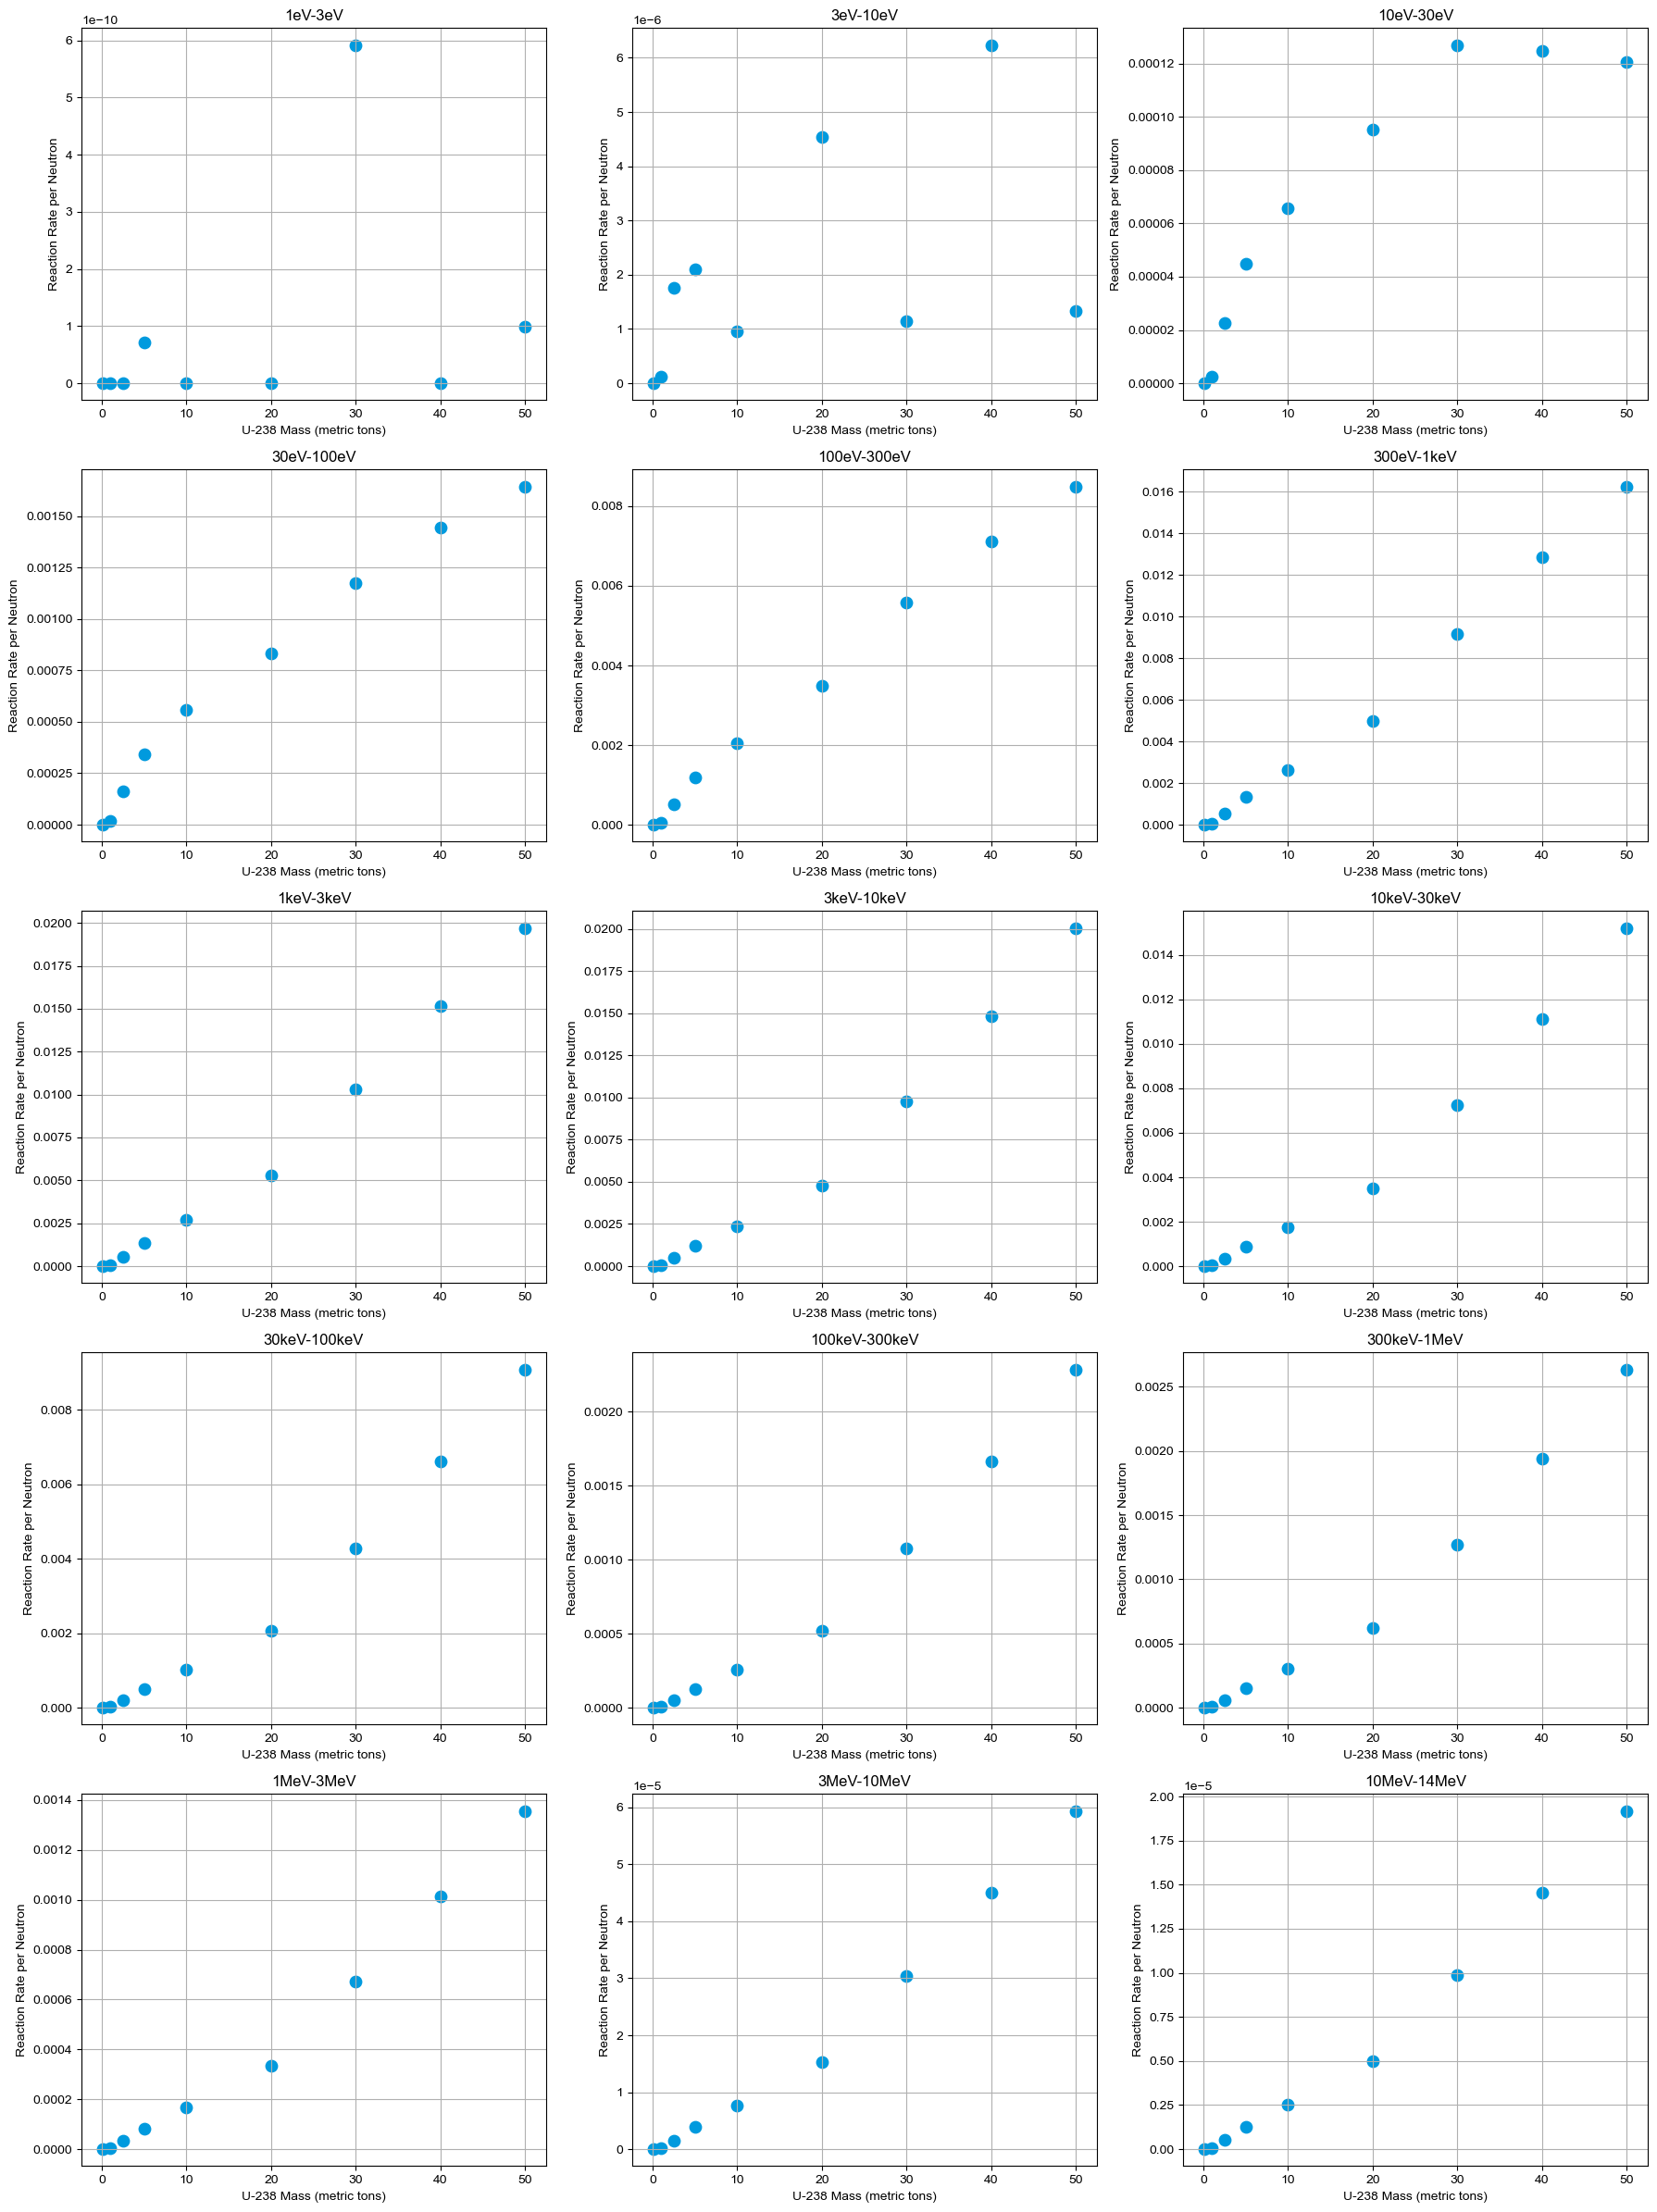

In [59]:
binstrings = ['1eV-3eV', '3eV-10eV', '10eV-30eV', '30eV-100eV', '100eV-300eV',
              '300eV-1keV', '1keV-3keV', '3keV-10keV', '10keV-30keV', '30keV-100keV',
              '100keV-300keV','300keV-1MeV', '1MeV-3MeV','3MeV-10MeV', '10MeV-14MeV']

bins_index = {
    '1eV-3eV': (1, 3),
    '3eV-10eV': (3, 10),
    '10eV-30eV': (10, 30),
    '30eV-100eV': (30, 100),
    '100eV-300eV': (100, 300),
    '300eV-1keV': (300, 1e3),
    '1keV-3keV': (1e3, 3e3),
    '3keV-10keV': (3e3, 10e3),
    '10keV-30keV': (10e3, 30e3),
    '30keV-100keV': (30e3, 100e3),
    '100keV-300keV': (100e3, 300e3),
    '300keV-1MeV': (300e3, 1e6),
    '1MeV-3MeV': (1e6, 3e6),
    '3MeV-10MeV': (3e6, 10e6),
    '10MeV-14MeV': (10e6, 14e6)
}

# Prepare subplots: 5 rows x 3 columns for 15 bins
fig, axes = plt.subplots(nrows=5, ncols=3, figsize=(18, 24))
axes = axes.flatten()

for i, binstring in enumerate(binstrings):
    ax = axes[i]
    E_low, E_high = bins_index[binstring]
    
    # Find bin indices where bin centers fall within your energy range
    bin_indices = np.where((E_bin_centers >= E_low) & (E_bin_centers < E_high))[0]
    
    x_mass = []
    y_rxn = []
    
    for label, mass in zip(mix_labels, U_masses): 
        # Sum the reaction rates in the specified energy bins
        rxn_binned = bin_summary[label]['U238_gamma_binned'][bin_indices].sum()
        
        x_mass.append(mass)
        y_rxn.append(rxn_binned)
    
    ax.scatter(x_mass, y_rxn, color='#009ade', s=80)
    ax.set_title(binstring)
    ax.set_xlabel('U-238 Mass (metric tons)')
    ax.set_ylabel('Reaction Rate per Neutron')
    ax.grid(True)

plt.tight_layout()
plt.show()
